In [11]:
import ast
import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
)

sys.path.append("..")

from config import MAX_K

In [13]:
plt.rcParams.update({
    "font.family": "Optima",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [14]:
path = Path("evaluation_results_model_triple_head.csv")
results_df = pd.read_csv(path)

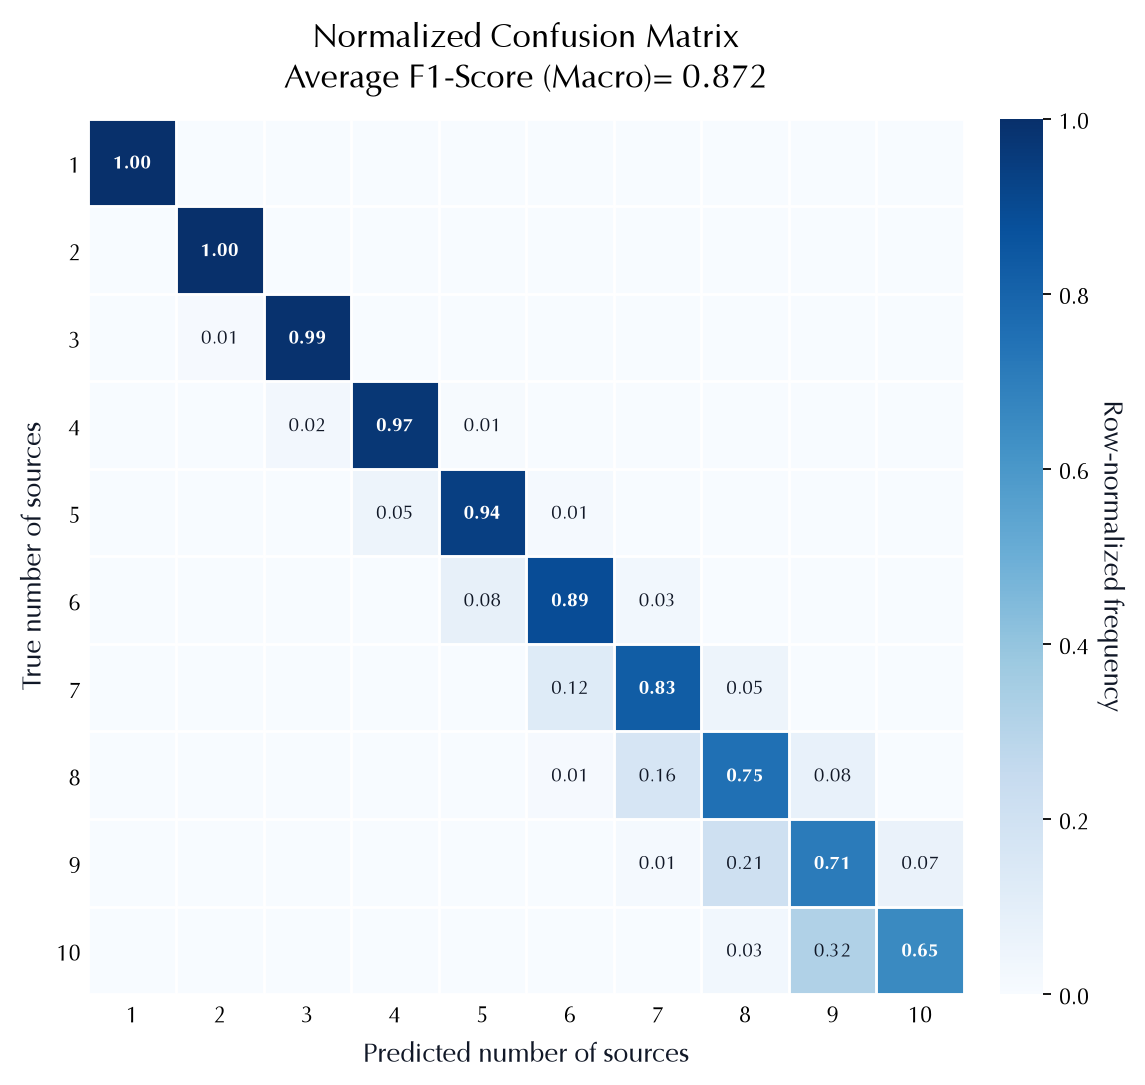

In [16]:
PRED_COL = "pred_K"
cm_df = results_df.copy()


labels = np.arange(1, int(max(cm_df["true_K"].max(), cm_df[PRED_COL].max())) + 1)
cm = confusion_matrix(cm_df["true_K"], cm_df[PRED_COL], labels=labels)
cm_norm = np.divide(
    cm,
    cm.sum(axis=1, keepdims=True),
    out=np.zeros_like(cm, dtype=float),
    where=cm.sum(axis=1, keepdims=True) != 0,
)
accuracy = np.mean(cm_df["true_K"].to_numpy() == cm_df[PRED_COL].to_numpy())
precision_macro = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
precision_weighted = precision_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)
f1_macro = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="macro", zero_division=0)
f1_weighted = f1_score(cm_df["true_K"], cm_df[PRED_COL], average="weighted", zero_division=0)


with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    # "axes.titleweight": "bold",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
}):
    fig, ax = plt.subplots(figsize=(8.4, 7.2), dpi=160)
    im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")

    # ax.set_title(f"Normalized Confusion Matrix\nAverage Accuracy = {accuracy:.3f}\nAverage Precision (Macro) = {precision_macro:.3f}\nAverage Precision (Weighted) = {precision_weighted:.3f}\nAverage F1-Score (Macro) = {f1_macro:.3f}\nAverage F1-Score (Weighted) = {f1_weighted:.3f}", pad=14)
    ax.set_title(f"Normalized Confusion Matrix\nAverage F1-Score (Macro)= {f1_macro:.3f}", pad=14)
    ax.set_xlabel("Predicted number of sources")
    ax.set_ylabel("True number of sources")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(labels), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.3)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.tick_params(axis="both", length=0)

    for i in range(cm_norm.shape[0]):
        for j in range(cm_norm.shape[1]):
            value = cm_norm[i, j]
            if value < 0.005:
                continue
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8.5,
                fontweight="bold" if i == j else "normal",
                color="white" if value > 0.45 else "#111827",
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.035)
    cbar.set_label("Row-normalized frequency", rotation=270, labelpad=18)
    cbar.outline.set_visible(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.88, bottom=0.1, top=0.86)
    plt.show()

Using 449,875/500,000 samples with true_K >= 2; weighted-F1 labels=[2, 3, 4, 5, 6, 7, 8, 9, 10]


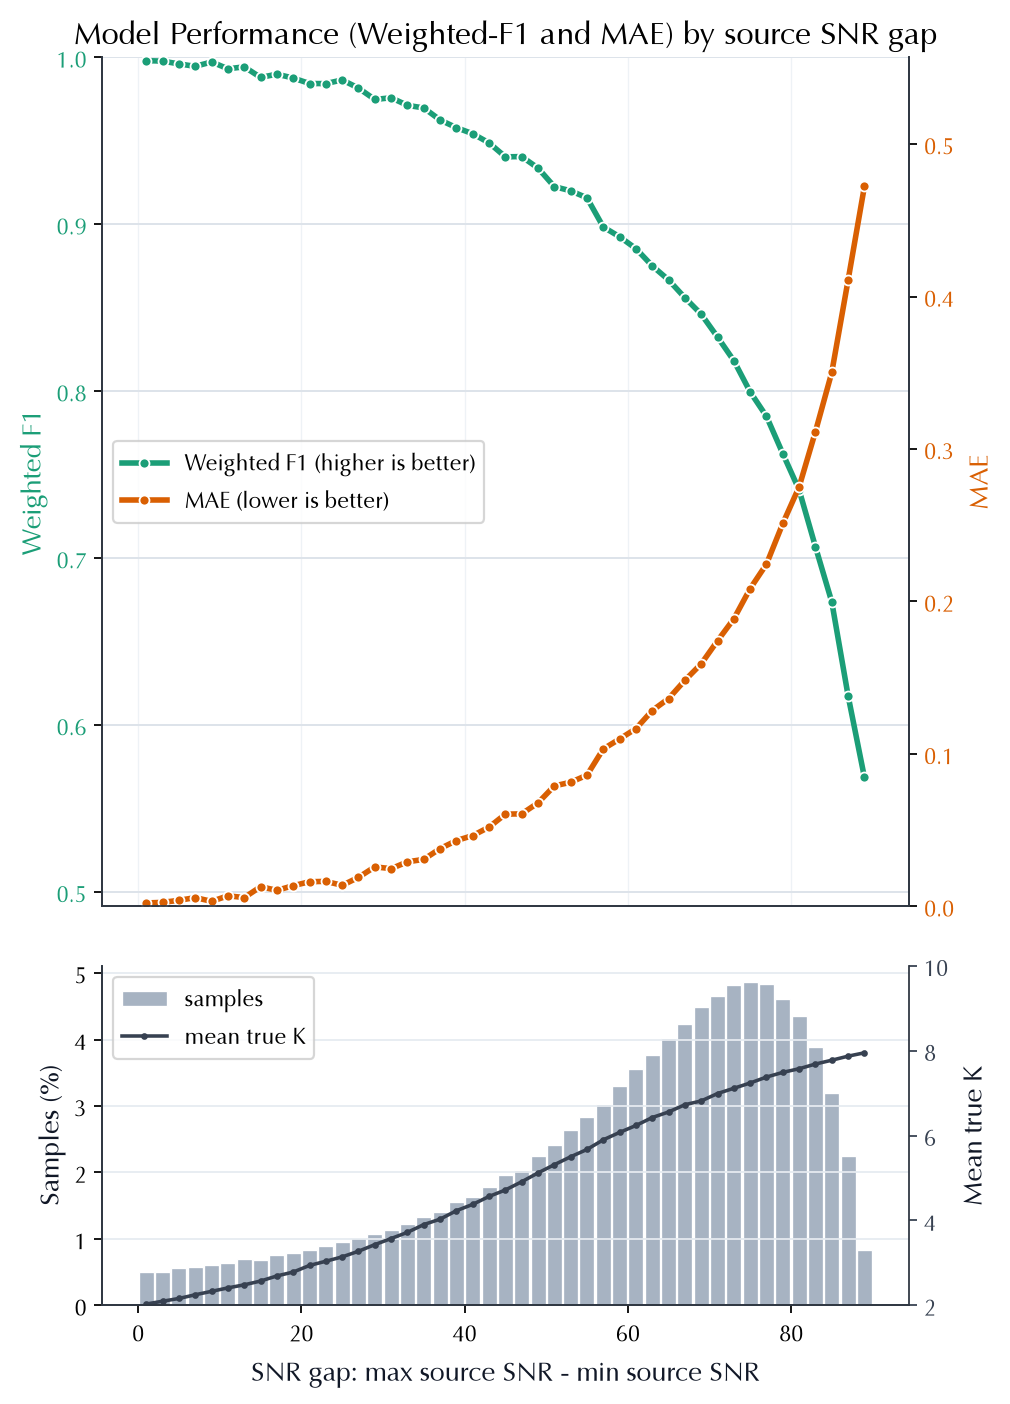

In [17]:
PRED_COL = "pred_K"
MIN_K_FOR_GAP_COMPARISON = 2
N_BINS = 45

snr_df = results_df.copy()

def parse_snr_values(values):
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=float)

snr_df = snr_df.copy()
snr_arrays = snr_df["snr_values"].map(parse_snr_values)
snr_df["snr_gap"] = snr_arrays.map(
    lambda values: float(values.max() - values.min()) if len(values) else np.nan
)
snr_df["true_K"] = snr_df["true_K"].astype(int)
snr_df[PRED_COL] = snr_df[PRED_COL].astype(int)

max_k = int(globals().get("MAX_K", max(snr_df["true_K"].max(), snr_df[PRED_COL].max())))
f1_labels = np.arange(MIN_K_FOR_GAP_COMPARISON, max_k + 1)

valid = np.isfinite(snr_df["snr_gap"]) & (snr_df["true_K"] >= MIN_K_FOR_GAP_COMPARISON)
analysis_df = snr_df.loc[valid].copy()
if analysis_df.empty:
    raise ValueError("No samples left after SNR-gap and K filtering")

print(
    f"Using {len(analysis_df):,}/{len(snr_df):,} samples with "
    f"true_K >= {MIN_K_FOR_GAP_COMPARISON}; weighted-F1 labels={f1_labels.tolist()}"
)

bin_edges = np.linspace(0.0, np.nanmax(analysis_df["snr_gap"]), N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

rows = []
for idx, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    if idx == len(bin_edges) - 2:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] <= right)
    else:
        mask = (analysis_df["snr_gap"] >= left) & (analysis_df["snr_gap"] < right)

    bin_df = analysis_df.loc[mask]
    n = int(len(bin_df))
    if n == 0:
        rows.append({
            "center": bin_centers[idx],
            "left": left,
            "right": right,
            "n": n,
            "sample_pct": 0.0,
            "mean_K": np.nan,
            "weighted_f1": np.nan,
            "mae": np.nan,
        })
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    rows.append({
        "center": bin_centers[idx],
        "left": left,
        "right": right,
        "n": n,
        "sample_pct": 100 * n / len(analysis_df),
        "mean_K": float(np.mean(y_true_bin)),
        "weighted_f1": f1_score(
            y_true_bin,
            y_pred_bin,
            labels=f1_labels,
            average="weighted",
            zero_division=0,
        ),
        "mae": mean_absolute_error(y_true_bin, y_pred_bin),
    })

metric_by_gap = pd.DataFrame(rows)
hist_frequency = metric_by_gap["sample_pct"].to_numpy()

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, axes = plt.subplots(
        2,
        1,
        figsize=(6, 10),
        dpi=160,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.1},
    )

    ax_curve = axes[0]
    ax_hist = axes[1]

    # Tracé du F1 Score (Axe gauche)
    color_f1 = "#1B9E77"
    line_f1 = ax_curve.plot(
        metric_by_gap["center"],
        metric_by_gap["weighted_f1"],
        color=color_f1,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="Weighted F1 (higher is better)"
    )
    ax_curve.set_ylabel("Weighted F1", color=color_f1)
    ax_curve.tick_params(axis="y", labelcolor=color_f1)
    ax_curve.grid(axis="y", color="#DDE3EA", linewidth=0.9)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    
    # Ajustement de l'axe y gauche
    f1_values = metric_by_gap["weighted_f1"].to_numpy(dtype=float)
    if np.isfinite(f1_values).any():
        y_min = np.nanmin(f1_values)
        y_max = np.nanmax(f1_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_curve.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))

    # Tracé de la MAE (Axe droit)
    ax_mae = ax_curve.twinx()
    color_mae = "#D95F02"
    line_mae = ax_mae.plot(
        metric_by_gap["center"],
        metric_by_gap["mae"],
        color=color_mae,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="MAE (lower is better)"
    )
    ax_mae.set_ylabel("MAE", color=color_mae)
    ax_mae.tick_params(axis="y", labelcolor=color_mae)

    # Ajustement de l'axe y droit
    mae_values = metric_by_gap["mae"].to_numpy(dtype=float)
    if np.isfinite(mae_values).any():
        y_min = np.nanmin(mae_values)
        y_max = np.nanmax(mae_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_mae.set_ylim(max(0.0, y_min - pad), y_max + pad)

    # ax_curve.set_title("Weighted F1 and MAE by source SNR gap")
    ax_curve.set_title("Model Performance (Weighted-F1 and MAE) by source SNR gap")

    # Regroupement des légendes
    lines = line_f1 + line_mae
    labels = [l.get_label() for l in lines]
    ax_curve.legend(lines, labels, loc="center left")

    # Histogramme en dessous
    bars = ax_hist.bar(
        bin_centers,
        hist_frequency,
        width=bin_widths * 0.92,
        align="center",
        color="#A7B3C2",
        edgecolor="white",
        linewidth=0.6,
        label="samples",
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel("SNR gap: max source SNR - min source SNR")
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.8)

    ax_k = ax_hist.twinx()
    line_k = ax_k.plot(
        metric_by_gap["center"],
        metric_by_gap["mean_K"],
        color="#374151",
        linewidth=1.6,
        marker=".",
        markersize=4,
        label="mean true K",
    )
    ax_k.set_ylabel("Mean true K")
    ax_k.set_ylim(MIN_K_FOR_GAP_COMPARISON, max_k)
    ax_k.tick_params(axis="y", colors="#374151")
    
    ax_hist.legend([bars, line_k[0]], ["samples", "mean true K"], loc="upper left")

    # Nettoyage des bordures
    ax_curve.spines["top"].set_visible(False)
    ax_mae.spines["top"].set_visible(False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_k.spines["top"].set_visible(False)

    # fig.suptitle(
    #     " ",
    #     fontsize=16,
    #     y=0.95,
    # )
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.1, top=0.88, hspace=0.1)
    plt.show()

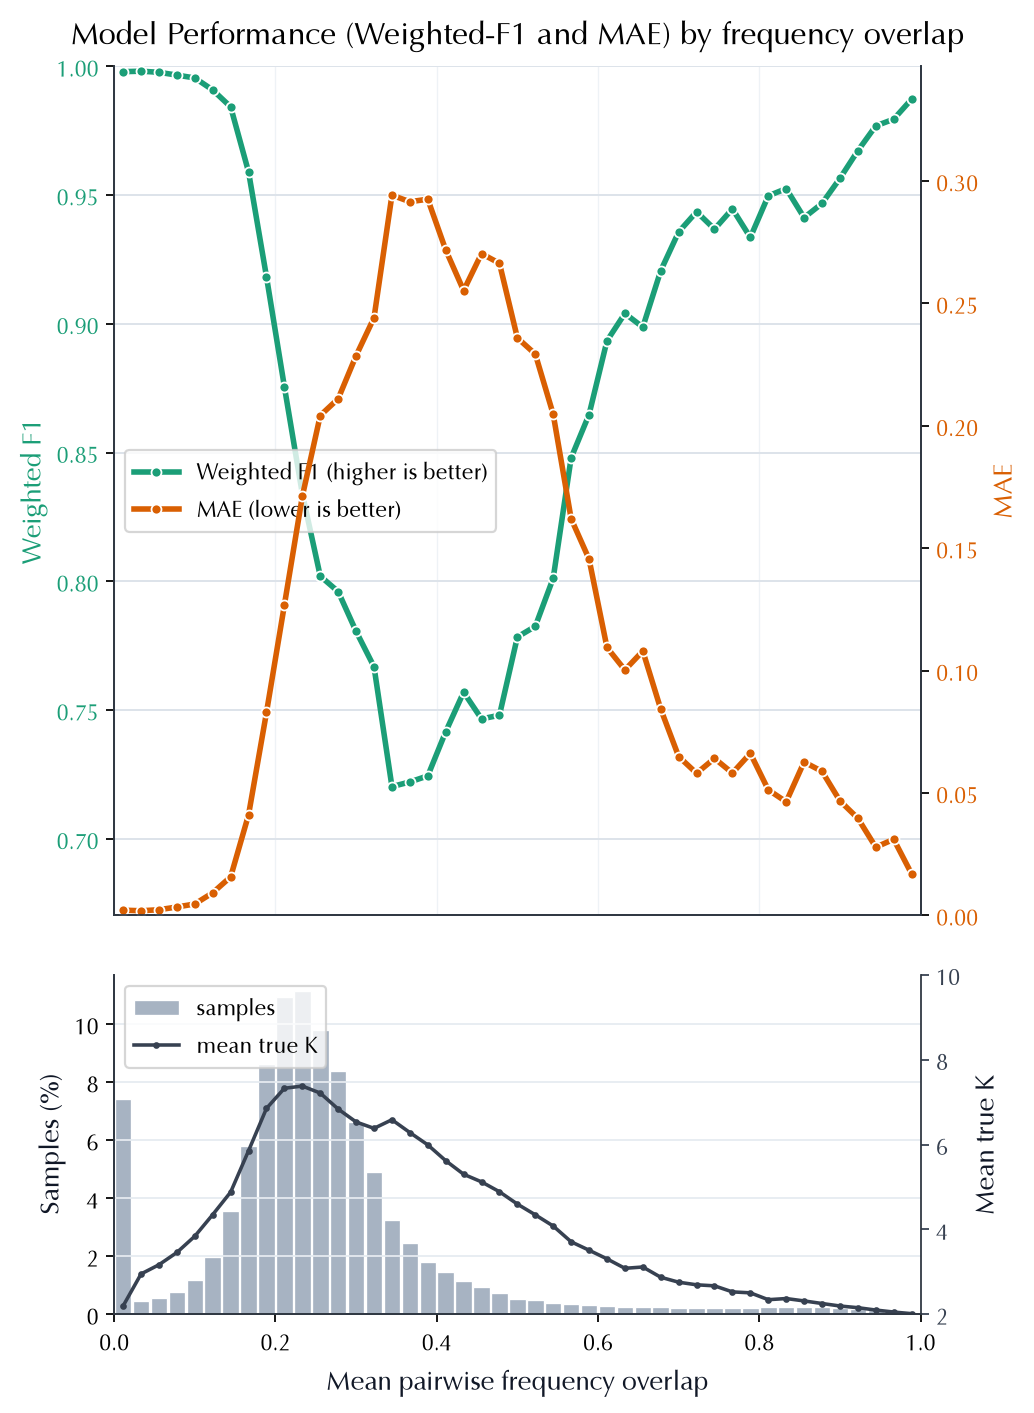

In [18]:
PRED_COL = "pred_K"
MIN_K_FOR_OVERLAP_COMPARISON = 2
N_OVERLAP_BINS = 45


def parse_frequency_bounds(values):
    if isinstance(values, str):
        values = ast.literal_eval(values)
    return np.asarray(values, dtype=int)


def mean_pairwise_frequency_overlap(starts, stops):
    starts = parse_frequency_bounds(starts)
    stops = parse_frequency_bounds(stops)
    intervals = [
        (int(start), int(stop))
        for start, stop in zip(starts, stops)
        if start >= 0 and stop > start
    ]

    if len(intervals) < 2:
        return 0.0

    directed_pairwise_overlaps = []
    for i, (start_i, stop_i) in enumerate(intervals):
        width_i = stop_i - start_i
        for j, (start_j, stop_j) in enumerate(intervals):
            if i == j:
                continue
            intersection = max(0, min(stop_i, stop_j) - max(start_i, start_j))
            directed_pairwise_overlaps.append(intersection / width_i)

    return float(np.mean(directed_pairwise_overlaps))


overlap_df = results_df.copy()
overlap_df["true_K"] = overlap_df["true_K"].astype(int)
overlap_df[PRED_COL] = overlap_df[PRED_COL].astype(int)
overlap_df["frequency_overlap"] = [
    mean_pairwise_frequency_overlap(starts, stops)
    for starts, stops in zip(overlap_df["freq_bin_start"], overlap_df["freq_bin_stop"])
]

analysis_df = overlap_df.loc[
    (overlap_df["true_K"] >= MIN_K_FOR_OVERLAP_COMPARISON)
    & np.isfinite(overlap_df["frequency_overlap"])
].copy()
if analysis_df.empty:
    raise ValueError("No samples left after frequency-overlap and K filtering")

max_k = int(max(analysis_df["true_K"].max(), analysis_df[PRED_COL].max()))
f1_labels = np.arange(MIN_K_FOR_OVERLAP_COMPARISON, max_k + 1)
bin_edges = np.linspace(0.0, 1.0, N_OVERLAP_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_widths = np.diff(bin_edges)

rows = []
for idx, (left, right) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
    if idx == N_OVERLAP_BINS - 1:
        mask = (analysis_df["frequency_overlap"] >= left) & (analysis_df["frequency_overlap"] <= right)
    else:
        mask = (analysis_df["frequency_overlap"] >= left) & (analysis_df["frequency_overlap"] < right)

    bin_df = analysis_df.loc[mask]
    n = len(bin_df)
    if n == 0:
        rows.append({
            "center": bin_centers[idx],
            "n": 0,
            "sample_pct": 0.0,
            "mean_K": np.nan,
            "weighted_f1": np.nan,
            "mae": np.nan,
        })
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    rows.append({
        "center": bin_centers[idx],
        "n": n,
        "sample_pct": 100 * n / len(analysis_df),
        "mean_K": float(np.mean(y_true_bin)),
        "weighted_f1": f1_score(
            y_true_bin,
            y_pred_bin,
            labels=f1_labels,
            average="weighted",
            zero_division=0,
        ),
        "mae": mean_absolute_error(y_true_bin, y_pred_bin),
    })

metric_by_overlap = pd.DataFrame(rows)

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#2F3742",
    "axes.labelcolor": "#111827",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, (ax_curve, ax_hist) = plt.subplots(
        2,
        1,
        figsize=(6, 10),
        dpi=160,
        sharex=True,
        gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.1},
    )

    color_f1 = "#1B9E77"
    line_f1 = ax_curve.plot(
        metric_by_overlap["center"],
        metric_by_overlap["weighted_f1"],
        color=color_f1,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="Weighted F1 (higher is better)",
    )
    ax_curve.set_ylabel("Weighted F1", color=color_f1)
    ax_curve.tick_params(axis="y", labelcolor=color_f1)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    ax_curve.grid(axis="y", color="#DDE3EA", linewidth=0.9)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)

    f1_values = metric_by_overlap["weighted_f1"].to_numpy(dtype=float)
    if np.isfinite(f1_values).any():
        y_min, y_max = np.nanmin(f1_values), np.nanmax(f1_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_curve.set_ylim(max(0.0, y_min - pad), min(1.0, y_max + pad))

    ax_mae = ax_curve.twinx()
    color_mae = "#D95F02"
    line_mae = ax_mae.plot(
        metric_by_overlap["center"],
        metric_by_overlap["mae"],
        color=color_mae,
        linewidth=2.5,
        marker="o",
        markersize=4.5,
        markeredgecolor="white",
        markeredgewidth=0.8,
        label="MAE (lower is better)",
    )
    ax_mae.set_ylabel("MAE", color=color_mae)
    ax_mae.tick_params(axis="y", labelcolor=color_mae)

    mae_values = metric_by_overlap["mae"].to_numpy(dtype=float)
    if np.isfinite(mae_values).any():
        y_min, y_max = np.nanmin(mae_values), np.nanmax(mae_values)
        pad = max((y_max - y_min) * 0.18, 0.015)
        ax_mae.set_ylim(max(0.0, y_min - pad), y_max + pad)

    # ax_curve.set_title("Weighted F1 and MAE by frequency overlap")
    ax_curve.set_title("Model Performance (Weighted-F1 and MAE) by frequency overlap", pad=10)
    lines = line_f1 + line_mae
    ax_curve.legend(lines, [line.get_label() for line in lines], loc="center left")

    bars = ax_hist.bar(
        bin_centers,
        metric_by_overlap["sample_pct"],
        width=bin_widths * 0.92,
        align="center",
        color="#A7B3C2",
        edgecolor="white",
        linewidth=0.6,
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel("Mean pairwise frequency overlap")
    ax_hist.set_xlim(0.0, 1.0)
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.8)

    ax_k = ax_hist.twinx()
    line_k = ax_k.plot(
        metric_by_overlap["center"],
        metric_by_overlap["mean_K"],
        color="#374151",
        linewidth=1.6,
        marker=".",
        markersize=4,
    )
    ax_k.set_ylabel("Mean true K")
    ax_k.set_ylim(MIN_K_FOR_OVERLAP_COMPARISON, max_k)
    ax_k.tick_params(axis="y", colors="#374151")
    ax_hist.legend([bars, line_k[0]], ["samples", "mean true K"], loc="upper left")

    ax_curve.spines["top"].set_visible(False)
    ax_mae.spines["top"].set_visible(False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)
    ax_k.spines["top"].set_visible(False)

    # fig.suptitle("Model performance by frequency overlap", fontsize=16, y=0.95)
    fig.subplots_adjust(left=0.08, right=0.92, bottom=0.1, top=0.88, hspace=0.1)
    plt.show()

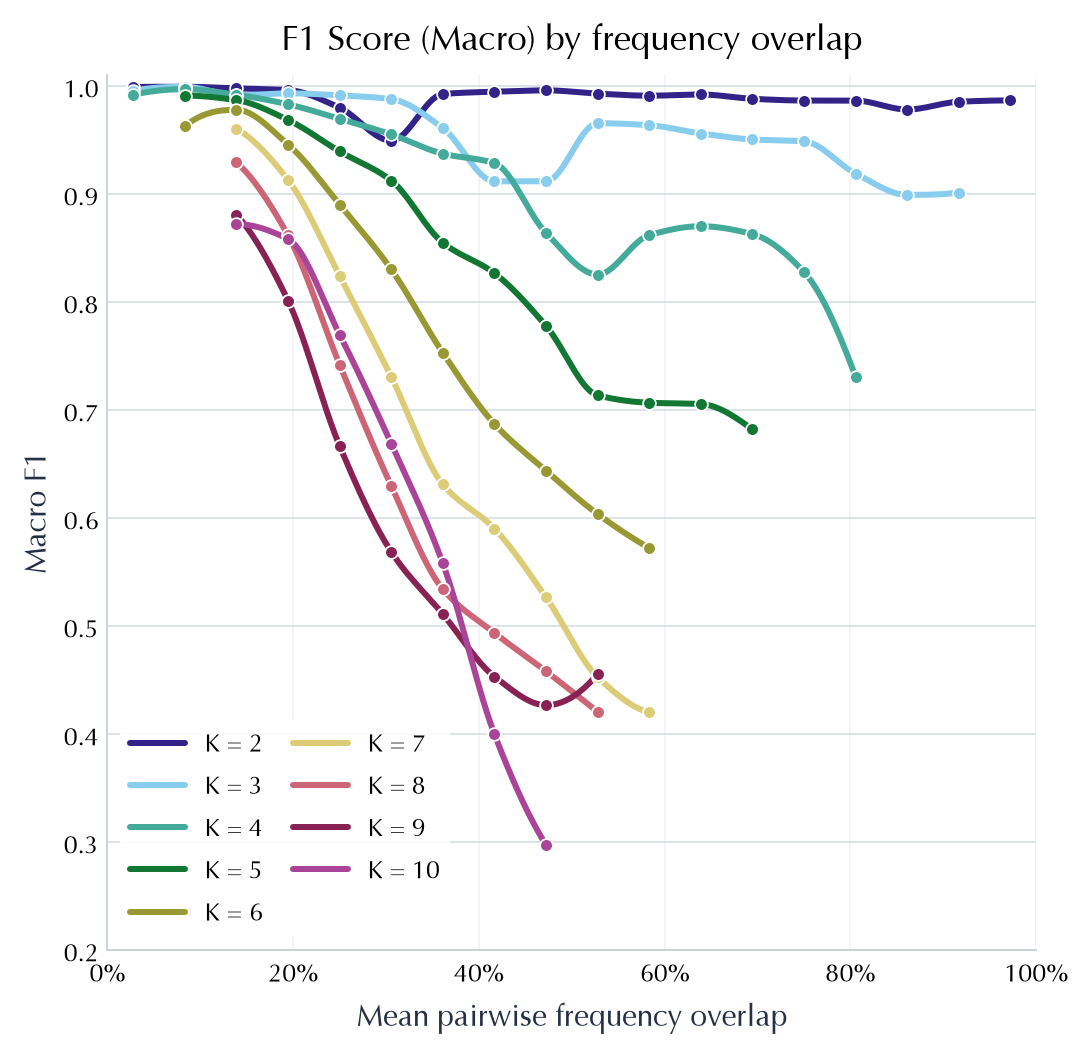

In [19]:
from matplotlib.ticker import PercentFormatter
from scipy.interpolate import PchipInterpolator

REPORT_INK = "#253047"
REPORT_GRID = "#DDE3EA"
N_CLASS_F1_BINS = 18
MIN_CLASS_SAMPLES_PER_BIN = 100

curve_df = analysis_df.copy()
k_values = np.sort(curve_df["true_K"].unique())
class_f1_edges = np.linspace(0.0, 1.0, N_CLASS_F1_BINS + 1)
class_f1_centers = 0.5 * (class_f1_edges[:-1] + class_f1_edges[1:])

class_f1_by_overlap = {k: np.full(N_CLASS_F1_BINS, np.nan) for k in k_values}
class_support_by_overlap = {k: np.zeros(N_CLASS_F1_BINS, dtype=int) for k in k_values}

for bin_idx, (left, right) in enumerate(zip(class_f1_edges[:-1], class_f1_edges[1:])):
    if bin_idx == N_CLASS_F1_BINS - 1:
        mask = (curve_df["frequency_overlap"] >= left) & (curve_df["frequency_overlap"] <= right)
    else:
        mask = (curve_df["frequency_overlap"] >= left) & (curve_df["frequency_overlap"] < right)

    bin_df = curve_df.loc[mask]
    if bin_df.empty:
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    for k in k_values:
        support = int(np.sum(y_true_bin == k))
        class_support_by_overlap[k][bin_idx] = support
        if support >= MIN_CLASS_SAMPLES_PER_BIN:
            class_f1_by_overlap[k][bin_idx] = f1_score(
                y_true_bin, y_pred_bin, labels=[k],
                average="macro", zero_division=0,
            )

curve_colors = [
    "#332288", "#88CCEE", "#44AA99",
    "#117733", "#999933", "#DDCC77",
    "#CC6677", "#882255", "#AA4499",
]

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CBD2DC",
    "axes.labelcolor": REPORT_INK,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, ax = plt.subplots(figsize=(6.0, 6.0), dpi=180)

    for color, k in zip(curve_colors, k_values):
        values = class_f1_by_overlap[k]
        valid = np.isfinite(values)
        x_valid = class_f1_centers[valid]
        y_valid = values[valid]
        if len(x_valid) >= 3:
            smooth_x = np.linspace(x_valid.min(), x_valid.max(), 250)
            smooth_y = np.clip(PchipInterpolator(x_valid, y_valid)(smooth_x), 0.0, 1.0)
            ax.plot(
                smooth_x, smooth_y, color=color, linewidth=2.4,
                solid_capstyle="round", label=f"K = {k}",
            )
            ax.scatter(
                x_valid, y_valid, color=color, s=26, zorder=3,
                edgecolor="white", linewidth=0.7,
            )
        elif len(x_valid):
            ax.plot(
                x_valid, y_valid, color=color, linewidth=2.4,
                marker="o", markersize=5, label=f"K = {k}",
            )

    finite_values = np.concatenate([
        values[np.isfinite(values)] for values in class_f1_by_overlap.values()
    ])
    if len(finite_values):
        lower_limit = max(0.0, np.floor((finite_values.min() - 0.04) * 10) / 10)
        ax.set_ylim(lower_limit, 1.01)

    ax.set_xlim(0.0, 1.0)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_xlabel("Mean pairwise frequency overlap")
    ax.set_ylabel("Macro F1")
    ax.set_title("F1 Score (Macro) by frequency overlap", loc="center", pad=10)

    ax.grid(axis="y", color=REPORT_GRID, linewidth=0.8)
    ax.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax.tick_params(axis="both", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="lower left", ncol=2,
        frameon=True, framealpha=0.92, facecolor="white",
        edgecolor="none", columnspacing=1.2, handlelength=2.2,
    )

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.93)
    plt.show()

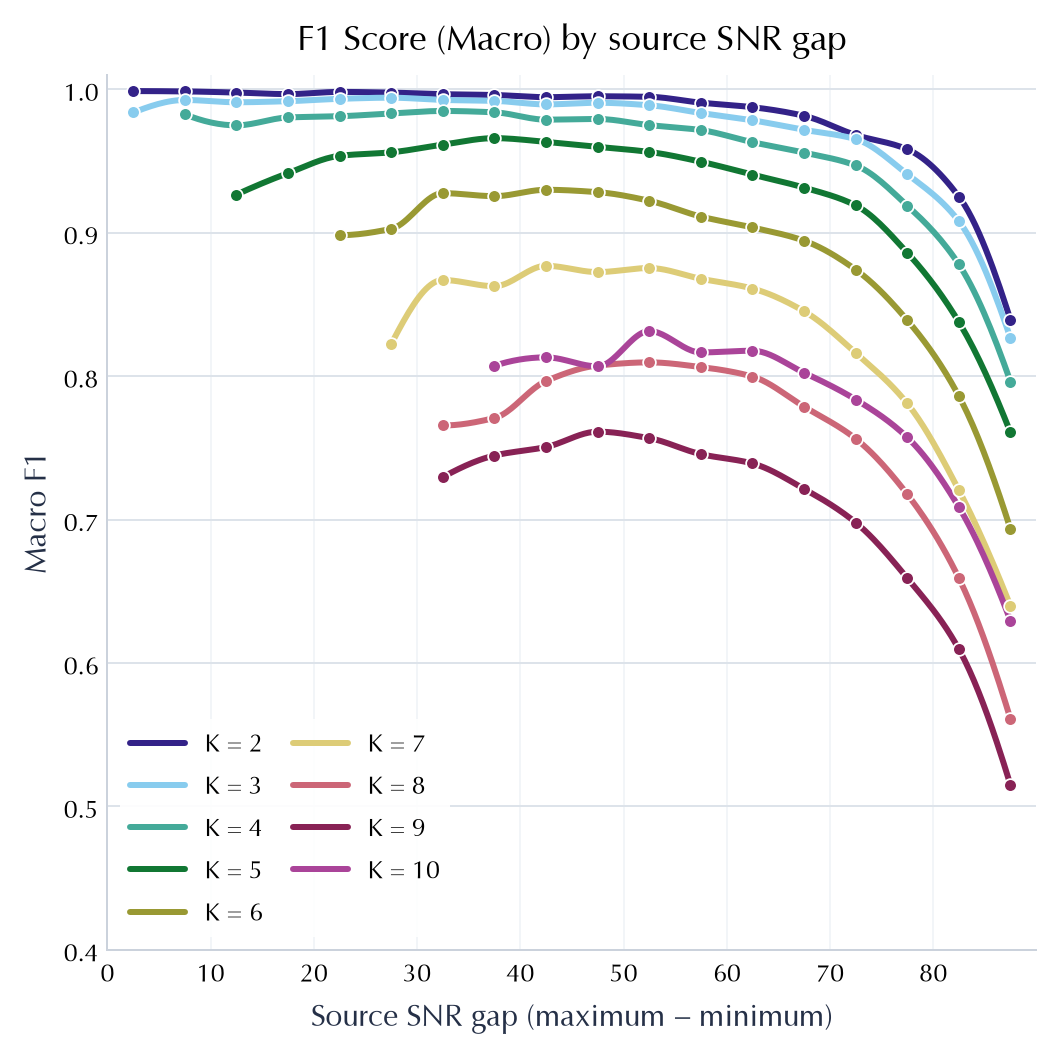

In [20]:
from scipy.interpolate import PchipInterpolator

SNR_F1_BINS = 18
MIN_SNR_CLASS_SAMPLES_PER_BIN = 100

snr_curve_df = snr_df.loc[
    np.isfinite(snr_df["snr_gap"])
    & (snr_df["true_K"] >= MIN_K_FOR_GAP_COMPARISON)
].copy()
snr_k_values = np.sort(snr_curve_df["true_K"].unique())
snr_f1_edges = np.linspace(0.0, snr_curve_df["snr_gap"].max(), SNR_F1_BINS + 1)
snr_f1_centers = 0.5 * (snr_f1_edges[:-1] + snr_f1_edges[1:])

class_f1_by_snr_gap = {k: np.full(SNR_F1_BINS, np.nan) for k in snr_k_values}

for bin_idx, (left, right) in enumerate(zip(snr_f1_edges[:-1], snr_f1_edges[1:])):
    if bin_idx == SNR_F1_BINS - 1:
        mask = (snr_curve_df["snr_gap"] >= left) & (snr_curve_df["snr_gap"] <= right)
    else:
        mask = (snr_curve_df["snr_gap"] >= left) & (snr_curve_df["snr_gap"] < right)

    bin_df = snr_curve_df.loc[mask]
    if bin_df.empty:
        continue

    y_true_bin = bin_df["true_K"].to_numpy()
    y_pred_bin = bin_df[PRED_COL].to_numpy()
    for k in snr_k_values:
        support = int(np.sum(y_true_bin == k))
        if support >= MIN_SNR_CLASS_SAMPLES_PER_BIN:
            class_f1_by_snr_gap[k][bin_idx] = f1_score(
                y_true_bin, y_pred_bin, labels=[k],
                average="macro", zero_division=0,
            )

snr_curve_colors = [
    "#332288", "#88CCEE", "#44AA99",
    "#117733", "#999933", "#DDCC77",
    "#CC6677", "#882255", "#AA4499",
]

with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CBD2DC",
    "axes.labelcolor": "#253047",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
}):
    fig, ax = plt.subplots(figsize=(6.0, 6.0), dpi=180)

    for color, k in zip(snr_curve_colors, snr_k_values):
        values = class_f1_by_snr_gap[k]
        valid = np.isfinite(values)
        x_valid = snr_f1_centers[valid]
        y_valid = values[valid]
        if len(x_valid) >= 3:
            smooth_x = np.linspace(x_valid.min(), x_valid.max(), 250)
            smooth_y = np.clip(PchipInterpolator(x_valid, y_valid)(smooth_x), 0.0, 1.0)
            ax.plot(
                smooth_x, smooth_y, color=color, linewidth=2.4,
                solid_capstyle="round", label=f"K = {k}",
            )
            ax.scatter(
                x_valid, y_valid, color=color, s=26, zorder=3,
                edgecolor="white", linewidth=0.7,
            )
        elif len(x_valid):
            ax.plot(
                x_valid, y_valid, color=color, linewidth=2.4,
                marker="o", markersize=5, label=f"K = {k}",
            )

    finite_values = np.concatenate([
        values[np.isfinite(values)] for values in class_f1_by_snr_gap.values()
    ])
    if len(finite_values):
        lower_limit = max(0.0, np.floor((finite_values.min() - 0.04) * 10) / 10)
        ax.set_ylim(lower_limit, 1.01)

    ax.set_xlim(snr_f1_edges[0], snr_f1_edges[-1])
    ax.set_xlabel("Source SNR gap (maximum − minimum)")
    ax.set_ylabel("Macro F1")
    ax.set_title("F1 Score (Macro) by source SNR gap", loc="center", pad=10)

    ax.grid(axis="y", color="#DDE3EA", linewidth=0.8)
    ax.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax.tick_params(axis="both", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(
        loc="lower left", ncol=2,
        frameon=True, framealpha=0.92, facecolor="white",
        edgecolor="none", columnspacing=1.2, handlelength=2.2,
    )

    fig.subplots_adjust(left=0.12, right=0.98, bottom=0.12, top=0.93)
    plt.show()

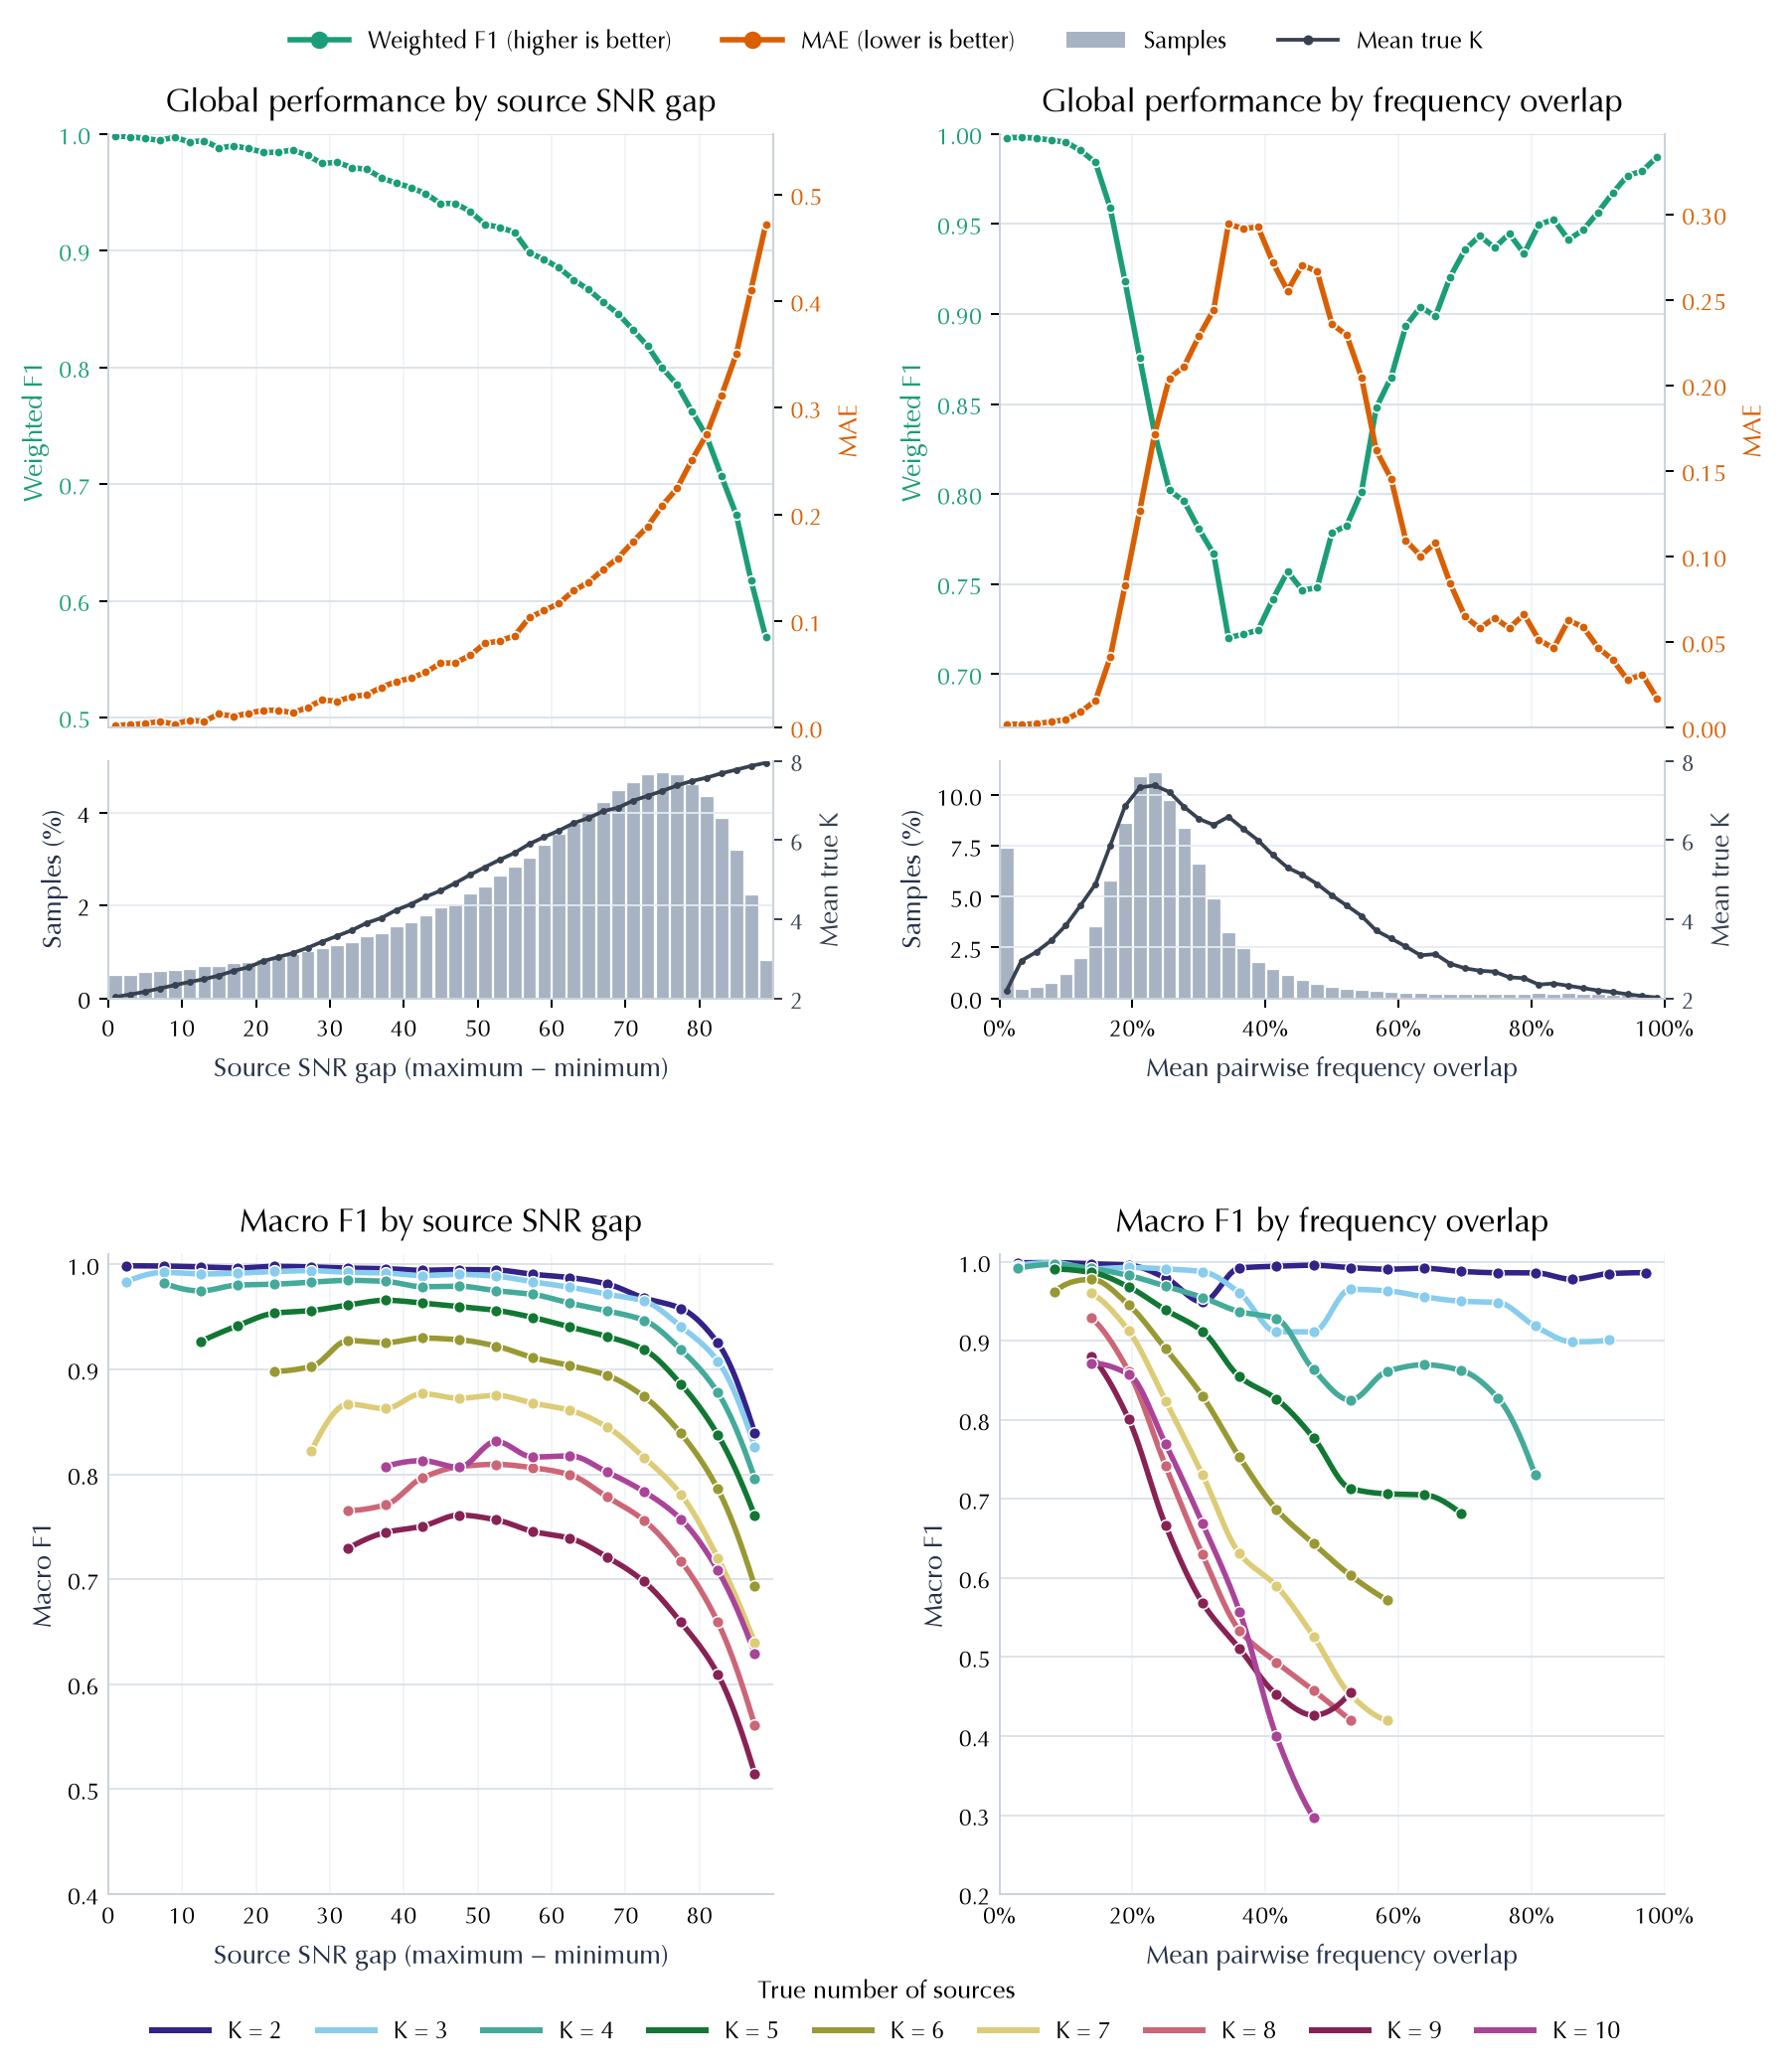

In [22]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Summary figure: the four previous views, with shared legends.
SUMMARY_F1_COLOR = "#1B9E77"
SUMMARY_MAE_COLOR = "#D95F02"
SUMMARY_HIST_COLOR = "#A7B3C2"
SUMMARY_K_COLOR = "#374151"
SUMMARY_GRID = "#DDE3EA"

all_k_values = np.union1d(snr_k_values, k_values)
k_color_map = {
    k: curve_colors[idx % len(curve_colors)]
    for idx, k in enumerate(all_k_values)
}


def _set_padded_ylim(ax, values, upper_bound=None):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if not len(values):
        return
    y_min, y_max = values.min(), values.max()
    pad = max((y_max - y_min) * 0.18, 0.015)
    upper = y_max + pad if upper_bound is None else min(upper_bound, y_max + pad)
    ax.set_ylim(max(0.0, y_min - pad), upper)


def _add_performance_panel(fig, slot, data, widths, title, xlabel, min_k, max_k, xlim=None, percent_x=False):
    panel = slot.subgridspec(2, 1, height_ratios=[2.5, 1.0], hspace=0.08)
    ax_curve = fig.add_subplot(panel[0])
    ax_hist = fig.add_subplot(panel[1], sharex=ax_curve)

    ax_curve.plot(
        data["center"], data["weighted_f1"],
        color=SUMMARY_F1_COLOR, linewidth=2.2, marker="o", markersize=3.8,
        markeredgecolor="white", markeredgewidth=0.7,
    )
    ax_curve.set_ylabel("Weighted F1", color=SUMMARY_F1_COLOR)
    ax_curve.tick_params(axis="y", labelcolor=SUMMARY_F1_COLOR)
    ax_curve.tick_params(axis="x", labelbottom=False, length=0)
    ax_curve.grid(axis="y", color=SUMMARY_GRID, linewidth=0.8)
    ax_curve.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    _set_padded_ylim(ax_curve, data["weighted_f1"], upper_bound=1.0)

    ax_mae = ax_curve.twinx()
    ax_mae.plot(
        data["center"], data["mae"],
        color=SUMMARY_MAE_COLOR, linewidth=2.2, marker="o", markersize=3.8,
        markeredgecolor="white", markeredgewidth=0.7,
    )
    ax_mae.set_ylabel("MAE", color=SUMMARY_MAE_COLOR)
    ax_mae.tick_params(axis="y", labelcolor=SUMMARY_MAE_COLOR)
    _set_padded_ylim(ax_mae, data["mae"])
    ax_curve.set_title(title, pad=9)

    ax_hist.bar(
        data["center"], data["sample_pct"], width=np.asarray(widths) * 0.92,
        color=SUMMARY_HIST_COLOR, edgecolor="white", linewidth=0.5,
    )
    ax_hist.set_ylabel("Samples (%)")
    ax_hist.set_xlabel(xlabel)
    ax_hist.grid(axis="y", color="#E6EBF1", linewidth=0.7)

    ax_mean_k = ax_hist.twinx()
    ax_mean_k.plot(
        data["center"], data["mean_K"],
        color=SUMMARY_K_COLOR, linewidth=1.5, marker=".", markersize=3.5,
    )
    ax_mean_k.set_ylabel("Mean true K", color=SUMMARY_K_COLOR)
    ax_mean_k.tick_params(axis="y", colors=SUMMARY_K_COLOR)
    ax_mean_k.set_ylim(min_k, max_k)

    if xlim is not None:
        ax_hist.set_xlim(*xlim)
    if percent_x:
        ax_hist.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))

    for axis in (ax_curve, ax_mae, ax_hist, ax_mean_k):
        axis.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)


def _add_class_f1_panel(ax, centers, values_by_k, title, xlabel, xlim, percent_x=False):
    finite_groups = []
    for k in all_k_values:
        if k not in values_by_k:
            continue
        values = np.asarray(values_by_k[k], dtype=float)
        valid = np.isfinite(values)
        x_valid, y_valid = np.asarray(centers)[valid], values[valid]
        if not len(x_valid):
            continue
        finite_groups.append(y_valid)
        color = k_color_map[k]
        if len(x_valid) >= 3:
            smooth_x = np.linspace(x_valid.min(), x_valid.max(), 250)
            smooth_y = np.clip(PchipInterpolator(x_valid, y_valid)(smooth_x), 0.0, 1.0)
            ax.plot(smooth_x, smooth_y, color=color, linewidth=2.2, solid_capstyle="round")
            ax.scatter(
                x_valid, y_valid, color=color, s=22, zorder=3,
                edgecolor="white", linewidth=0.6,
            )
        else:
            ax.plot(x_valid, y_valid, color=color, linewidth=2.2, marker="o", markersize=4.5)

    if finite_groups:
        minimum = np.concatenate(finite_groups).min()
        ax.set_ylim(max(0.0, np.floor((minimum - 0.04) * 10) / 10), 1.01)
    ax.set_xlim(*xlim)
    if percent_x:
        ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Macro F1")
    ax.set_title(title, pad=9)
    ax.grid(axis="y", color=SUMMARY_GRID, linewidth=0.8)
    ax.grid(axis="x", color="#EEF2F6", linewidth=0.6)
    ax.tick_params(axis="both", length=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


with plt.rc_context({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#CBD2DC",
    "axes.labelcolor": "#253047",
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9.5,
}):
    fig = plt.figure(figsize=(10, 12), dpi=180)
    outer = fig.add_gridspec(
        2, 2, height_ratios=[1.35, 1.0],
        left=0.065, right=0.935, bottom=0.105, top=0.925,
        wspace=0.34, hspace=0.34,
    )

    gap_widths = (metric_by_gap["right"] - metric_by_gap["left"]).to_numpy()
    overlap_widths = np.full(len(metric_by_overlap), 1.0 / N_OVERLAP_BINS)
    _add_performance_panel(
        fig, outer[0, 0], metric_by_gap, gap_widths,
        "Global performance by source SNR gap",
        "Source SNR gap (maximum − minimum)",
        MIN_K_FOR_GAP_COMPARISON, int(np.ceil(metric_by_gap["mean_K"].max())),
        xlim=(metric_by_gap["left"].min(), metric_by_gap["right"].max()),
    )
    _add_performance_panel(
        fig, outer[0, 1], metric_by_overlap, overlap_widths,
        "Global performance by frequency overlap",
        "Mean pairwise frequency overlap",
        MIN_K_FOR_OVERLAP_COMPARISON, int(np.ceil(metric_by_overlap["mean_K"].max())),
        xlim=(0.0, 1.0), percent_x=True,
    )

    ax_snr_class = fig.add_subplot(outer[1, 0])
    ax_overlap_class = fig.add_subplot(outer[1, 1])
    _add_class_f1_panel(
        ax_snr_class, snr_f1_centers, class_f1_by_snr_gap,
        "Macro F1 by source SNR gap",
        "Source SNR gap (maximum − minimum)",
        (snr_f1_edges[0], snr_f1_edges[-1]),
    )
    _add_class_f1_panel(
        ax_overlap_class, class_f1_centers, class_f1_by_overlap,
        "Macro F1 by frequency overlap",
        "Mean pairwise frequency overlap",
        (0.0, 1.0), percent_x=True,
    )

    performance_handles = [
        Line2D([], [], color=SUMMARY_F1_COLOR, linewidth=2.2, marker="o", label="Weighted F1 (higher is better)"),
        Line2D([], [], color=SUMMARY_MAE_COLOR, linewidth=2.2, marker="o", label="MAE (lower is better)"),
        Patch(facecolor=SUMMARY_HIST_COLOR, edgecolor="none", label="Samples"),
        Line2D([], [], color=SUMMARY_K_COLOR, linewidth=1.5, marker=".", label="Mean true K"),
    ]
    fig.legend(
        handles=performance_handles, loc="upper center", bbox_to_anchor=(0.5, 0.985),
        ncol=4, frameon=False, columnspacing=2.2, handlelength=2.5,
    )

    class_handles = [
        Line2D([], [], color=k_color_map[k], linewidth=2.4, label=f"K = {k}")
        for k in all_k_values
    ]
    fig.legend(
        handles=class_handles, loc="lower center", bbox_to_anchor=(0.5, 0.025),
        ncol=min(len(class_handles), 9), frameon=False,
        columnspacing=1.5, handlelength=2.4, title="True number of sources",
    )

    plt.show()